# ModToken Experiment Results Analysis

Analysis of PyTorch model experiments on the GLOBEM benchmark.
Covers all 4 evaluation tasks: allbutone, single_within_user, crosscovid, two_overlap.

In [1]:
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

sys.path.insert(0, os.path.abspath('..'))

%matplotlib inline

In [2]:
# --- Configuration ---

EVAL_OUTPUT = "../evaluation_output"
DS_KEYS = ["INS-W_1", "INS-W_2", "INS-W_3", "INS-W_4"]
CROSSCOVID_KEYS = ["INS-W_1:INS-W_2", "INS-W_3:INS-W_4"]

TASK_DIRS = {
    "allbutone":        "evaluation_allbutone_datasets/dep_weekly",
    "single_within_user": "evaluation_single_dataset_within_user/dep_weekly",
    "crosscovid":       "evaluation_crosscovid_datasets/dep_weekly",
    "two_overlap":      "evaluation_two_datasets_overlap/dep_weekly",
}

# Model display names and ordering
MODEL_ORDER = [
    "dl_torch_reorder_cnn",               # M0
    "dl_torch_erm_transformer",            # M2
    "dl_torch_reorder_transformer",        # M3
    "dl_torch_reorder_deep",               # M6
    "dl_torch_modality_token",             # M7
    "dl_torch_modality_token_reorder",     # M7r
    "dl_torch_modality_token_reorder_mae", # M7r+MAE
    "dl_torch_reorder_cnn_aug",            # M0+AUG
    "dl_torch_modality_token_reorder_aug", # M7r+AUG
    "dl_torch_reorder_cnn_imp",            # M0+IMP
    "dl_torch_modality_token_reorder_imp", # M7r+IMP
]

MODEL_DISPLAY = {
    "dl_torch_reorder_cnn":               "M0: Reorder-CNN",
    "dl_torch_erm_transformer":            "M2: ERM-Transformer",
    "dl_torch_reorder_transformer":        "M3: Reorder-Transformer",
    "dl_torch_reorder_deep":               "M6: Reorder-Deep",
    "dl_torch_modality_token":             "M7: ModToken",
    "dl_torch_modality_token_reorder":     "M7r: ModToken+Reorder",
    "dl_torch_modality_token_reorder_mae": "M7r+MAE",
    "dl_torch_reorder_cnn_aug":            "M0+AUG",
    "dl_torch_modality_token_reorder_aug": "M7r+AUG",
    "dl_torch_reorder_cnn_imp":            "M0+IMP",
    "dl_torch_modality_token_reorder_imp": "M7r+IMP",
}

TASK_DISPLAY = {
    "allbutone": "Leave-One-Out",
    "single_within_user": "Within-User",
    "crosscovid": "Cross-COVID",
    "two_overlap": "Overlapping Users",
}

In [3]:
# --- Load results ---

def load_task_results(task_name, task_dir):
    """Load all dl_torch pkl results for a given eval task."""
    folder = os.path.join(EVAL_OUTPUT, task_dir)
    if not os.path.isdir(folder):
        return pd.DataFrame()
    
    rows = []
    for pkl_path in glob.glob(os.path.join(folder, "dl_torch*.pkl")):
        model_name = os.path.splitext(os.path.basename(pkl_path))[0]
        with open(pkl_path, "rb") as f:
            results = pickle.load(f)
        
        for pred_target, results_dict in results["results_repo"].items():
            for ds_test, results_dict_test in results_dict.items():
                d = {"task": task_name, "model": model_name,
                     "ds_test": ds_test, "pred_target": pred_target}
                # two_overlap has an extra nesting level
                if task_name == "two_overlap" and isinstance(results_dict_test, dict):
                    inner_key = list(results_dict_test.keys())
                    if inner_key and isinstance(results_dict_test[inner_key[0]], dict):
                        results_dict_test = results_dict_test[inner_key[0]]
                d.update(results_dict_test)
                rows.append(d)
    
    return pd.DataFrame(rows)

# Load all tasks
all_results = {}
for task_name, task_dir in TASK_DIRS.items():
    df = load_task_results(task_name, task_dir)
    if not df.empty:
        all_results[task_name] = df
        print(f"{task_name}: {df['model'].nunique()} models, {len(df)} rows")
    else:
        print(f"{task_name}: NO RESULTS FOUND")

print(f"\nTotal tasks loaded: {len(all_results)}")

allbutone: 8 models, 32 rows
single_within_user: 8 models, 32 rows
crosscovid: 8 models, 16 rows
two_overlap: 8 models, 32 rows

Total tasks loaded: 4


In [4]:
# --- Helper functions ---

def pivot_metric(df, metric, ds_keys=None):
    """Pivot results into model x dataset table with Avg and SEM columns."""
    pivot = df.pivot_table(index="model", columns="ds_test", values=metric, aggfunc="first")
    if ds_keys is not None:
        pivot = pivot.reindex(columns=[k for k in ds_keys if k in pivot.columns])
    pivot["Avg"] = pivot.mean(axis=1)
    n_folds = pivot.shape[1] - 1  # exclude Avg column
    pivot["SEM"] = pivot.iloc[:, :-1].std(axis=1) / np.sqrt(n_folds)
    
    # Reorder by MODEL_ORDER
    order = [m for m in MODEL_ORDER if m in pivot.index]
    extra = [m for m in pivot.index if m not in MODEL_ORDER]
    pivot = pivot.reindex(order + extra)
    return pivot


def format_table(pivot, display_names=True):
    """Format pivot table for display with model names and +/- SEM."""
    df = pivot.copy()
    if display_names:
        df.index = [MODEL_DISPLAY.get(m, m) for m in df.index]
    return df.style.format("{:.3f}").highlight_max(subset=["Avg"], color="#d4edda")


def get_ds_keys_for_task(task_name):
    if task_name == "crosscovid":
        return CROSSCOVID_KEYS
    return DS_KEYS

## Per-Task Results Tables

In [5]:
pivots = {}  # (task, metric) -> pivot table

for task_name, df in all_results.items():
    ds_keys = get_ds_keys_for_task(task_name)
    print(f"\n{'='*80}")
    print(f"  {TASK_DISPLAY[task_name]} ({task_name})")
    print(f"{'='*80}")
    
    for metric, label in [("test_balanced_acc", "Balanced Accuracy"),
                           ("test_roc_auc", "ROC AUC")]:
        pivot = pivot_metric(df, metric, ds_keys)
        pivots[(task_name, metric)] = pivot
        print(f"\n--- {label} ---")
        display_df = pivot.copy()
        display_df.index = [MODEL_DISPLAY.get(m, m) for m in display_df.index]
        print(display_df.round(3).to_string())


  Leave-One-Out (allbutone)

--- Balanced Accuracy ---
ds_test                INS-W_1  INS-W_2  INS-W_3  INS-W_4    Avg    SEM
M0: Reorder-CNN          0.549    0.565    0.522    0.539  0.544  0.009
M2: ERM-Transformer      0.572    0.554    0.525    0.540  0.548  0.010
M4b: MAE-Transformer     0.547    0.552    0.531    0.547  0.544  0.005
M7: ModToken             0.559    0.540    0.548    0.564  0.553  0.005
M7r: ModToken+Reorder    0.559    0.549    0.543    0.566  0.554  0.005
M7r+MAE                  0.561    0.554    0.566    0.563  0.561  0.003
M7r+AUG                  0.518    0.564    0.553    0.581  0.554  0.013
M7r+IMP                  0.570    0.501    0.568    0.503  0.536  0.019

--- ROC AUC ---
ds_test                INS-W_1  INS-W_2  INS-W_3  INS-W_4    Avg    SEM
M0: Reorder-CNN          0.557    0.595    0.559    0.562  0.568  0.009
M2: ERM-Transformer      0.581    0.561    0.529    0.570  0.560  0.011
M4b: MAE-Transformer     0.582    0.581    0.535    0.576  0.56

## Summary: Average Balanced Accuracy Across All Tasks

In [6]:
# Combine Avg balanced accuracy across all tasks
summary_rows = []
for task_name in TASK_DIRS:
    key = (task_name, "test_balanced_acc")
    if key in pivots:
        col = pivots[key]["Avg"].rename(TASK_DISPLAY[task_name])
        summary_rows.append(col)

if summary_rows:
    summary = pd.concat(summary_rows, axis=1)
    summary["Grand Avg"] = summary.mean(axis=1)
    
    # Reorder
    order = [m for m in MODEL_ORDER if m in summary.index]
    extra = [m for m in summary.index if m not in MODEL_ORDER]
    summary = summary.reindex(order + extra)
    summary.index = [MODEL_DISPLAY.get(m, m) for m in summary.index]
    
    print(summary.round(3).to_string())

                       Leave-One-Out  Within-User  Cross-COVID  Overlapping Users  Grand Avg
M0: Reorder-CNN                0.544        0.587        0.525              0.589      0.561
M2: ERM-Transformer            0.548        0.566        0.516              0.593      0.556
M4b: MAE-Transformer           0.544        0.574        0.552              0.610      0.570
M7: ModToken                   0.553        0.616        0.538              0.580      0.572
M7r: ModToken+Reorder          0.554        0.653        0.525              0.606      0.584
M7r+MAE                        0.561        0.652        0.527              0.596      0.584
M7r+AUG                        0.554        0.657        0.532              0.616      0.590
M7r+IMP                        0.536        0.551        0.512              0.594      0.548


## Bar Charts: Per-Task Performance

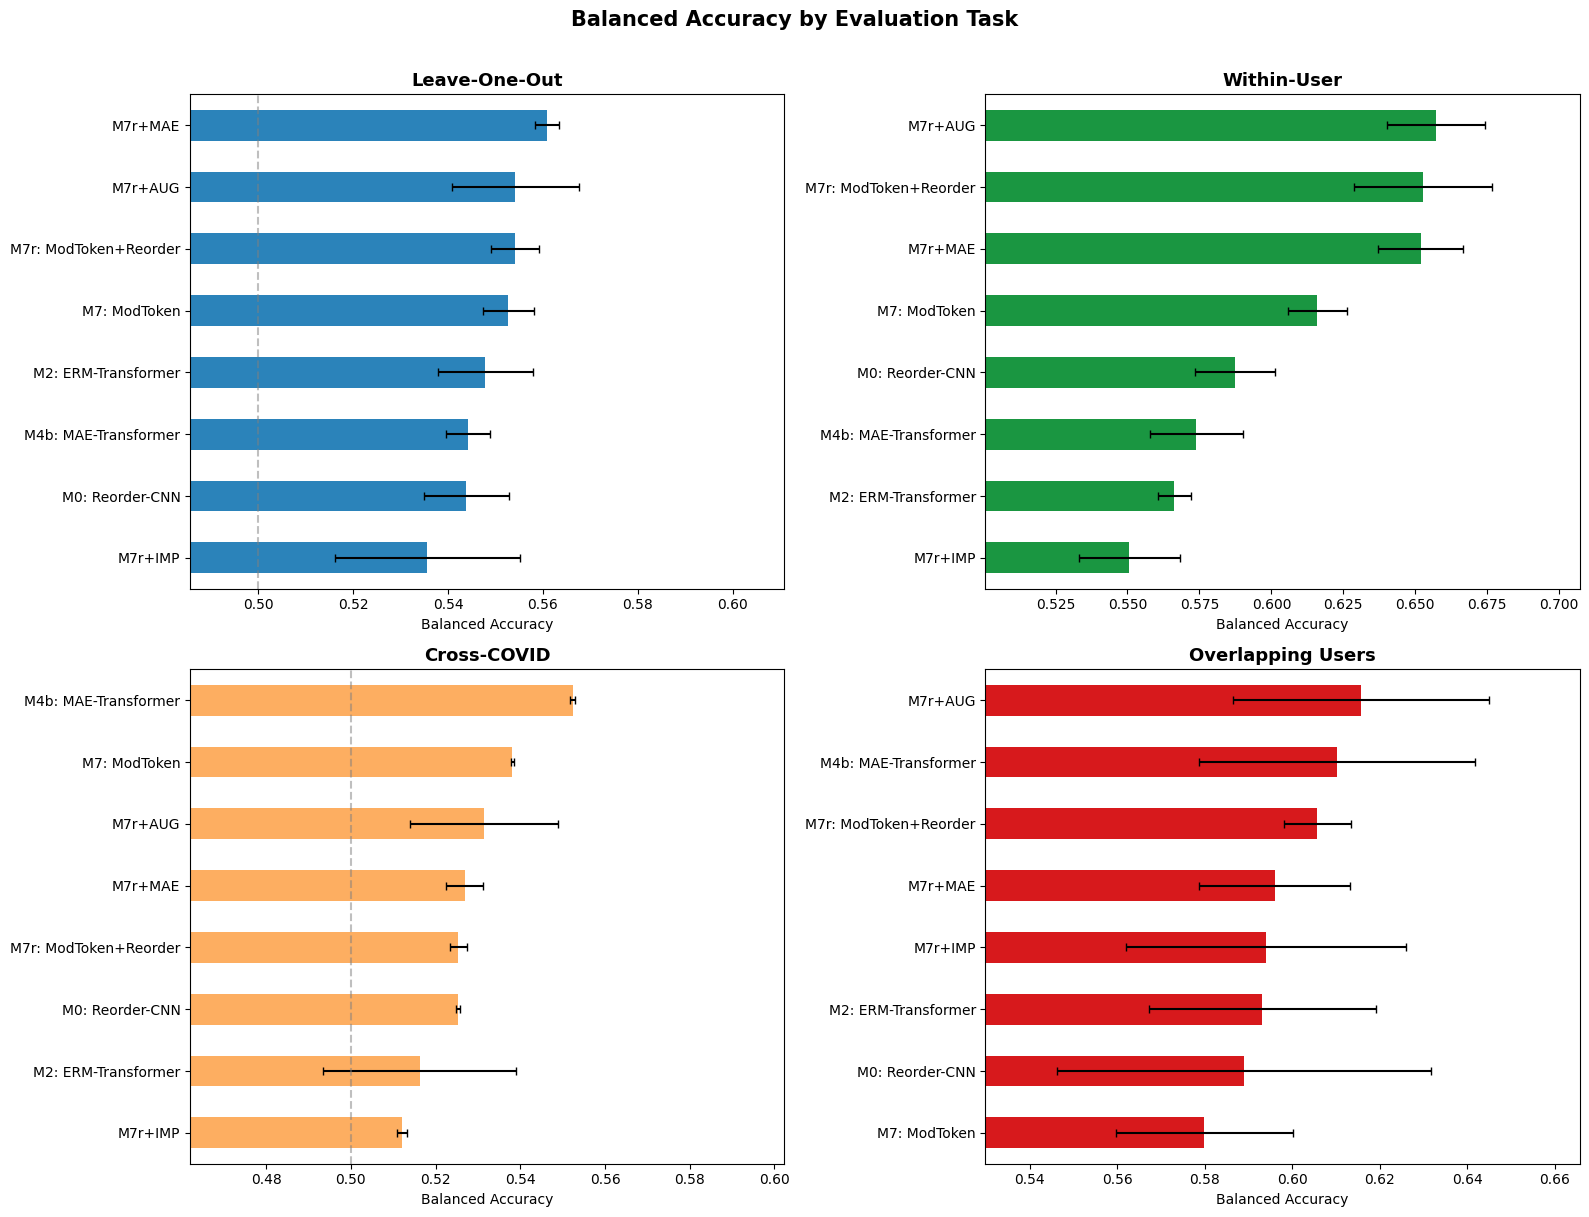

In [7]:
task_colors = {
    "allbutone": "#2b83ba",
    "single_within_user": "#1a9641",
    "crosscovid": "#fdae61",
    "two_overlap": "#d7191c",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (task_name, task_dir) in enumerate(TASK_DIRS.items()):
    ax = axes[i]
    key = (task_name, "test_balanced_acc")
    if key not in pivots:
        ax.set_title(f"{TASK_DISPLAY[task_name]} â€” no results")
        continue
    
    pivot = pivots[key]
    avg = pivot["Avg"].copy()
    sem = pivot["SEM"].copy()
    avg.index = [MODEL_DISPLAY.get(m, m) for m in avg.index]
    sem.index = avg.index
    
    avg_sorted = avg.sort_values(ascending=True)
    sem_sorted = sem.reindex(avg_sorted.index)
    
    avg_sorted.plot.barh(
        ax=ax, xerr=sem_sorted, color=task_colors[task_name],
        error_kw=dict(lw=1.5, capsize=3, capthick=1)
    )
    ax.set_title(TASK_DISPLAY[task_name], fontsize=13, fontweight="bold")
    ax.set_xlabel("Balanced Accuracy")
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="chance")
    
    # Set reasonable x limits
    xmin = max(0.4, avg.min() - 0.05)
    xmax = min(1.0, avg.max() + 0.05)
    ax.set_xlim(xmin, xmax)

fig.suptitle("Balanced Accuracy by Evaluation Task", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/torch_results_all_tasks.png", dpi=150, bbox_inches="tight")
plt.show()

## Ablation Comparisons

Key pairwise comparisons from the research plan (Section 4.5).

In [8]:
ABLATIONS = [
    ("Architecture (CNN vs Transformer)",   "dl_torch_reorder_cnn",               "dl_torch_reorder_transformer"),
    ("Reorder effect (flat)",               "dl_torch_erm_transformer",            "dl_torch_reorder_transformer"),
    ("Capacity (4L vs 6L)",                 "dl_torch_reorder_transformer",        "dl_torch_reorder_deep"),
    ("Modality structure",                  "dl_torch_reorder_cnn",               "dl_torch_modality_token"),
    ("Reorder effect (modality)",           "dl_torch_modality_token",             "dl_torch_modality_token_reorder"),
    ("MAE pretrain (modality)",             "dl_torch_modality_token_reorder",     "dl_torch_modality_token_reorder_mae"),
    ("Augmentation (CNN)",                  "dl_torch_reorder_cnn",               "dl_torch_reorder_cnn_aug"),
    ("Augmentation (ModToken)",             "dl_torch_modality_token_reorder",     "dl_torch_modality_token_reorder_aug"),
    ("Imputation (CNN)",                    "dl_torch_reorder_cnn",               "dl_torch_reorder_cnn_imp"),
    ("Imputation (ModToken)",               "dl_torch_modality_token_reorder",     "dl_torch_modality_token_reorder_imp"),
]

# Focus on allbutone (primary benchmark) balanced accuracy
primary_task = "allbutone"
primary_key = (primary_task, "test_balanced_acc")

if primary_key in pivots:
    pivot = pivots[primary_key]
    
    ablation_rows = []
    for label, model_a, model_b in ABLATIONS:
        if model_a in pivot.index and model_b in pivot.index:
            avg_a = pivot.loc[model_a, "Avg"]
            avg_b = pivot.loc[model_b, "Avg"]
            delta = avg_b - avg_a
            
            # Per-fold differences for paired t-test
            ds_keys = get_ds_keys_for_task(primary_task)
            available = [k for k in ds_keys if k in pivot.columns]
            diffs = pivot.loc[model_b, available].values - pivot.loc[model_a, available].values
            
            from scipy import stats
            if len(diffs) >= 2:
                t_stat, p_val = stats.ttest_1samp(diffs, 0)
            else:
                t_stat, p_val = np.nan, np.nan
            
            direction = "+" if delta > 0 else "-" if delta < 0 else "="
            
            ablation_rows.append({
                "Comparison": label,
                "Baseline": MODEL_DISPLAY.get(model_a, model_a),
                "Treatment": MODEL_DISPLAY.get(model_b, model_b),
                "Baseline Avg": f"{avg_a:.3f}",
                "Treatment Avg": f"{avg_b:.3f}",
                "Delta": f"{direction}{abs(delta):.3f}",
                "p-value": f"{p_val:.3f}" if not np.isnan(p_val) else "N/A",
                "Consistent": "Yes" if all(d > 0 for d in diffs) or all(d < 0 for d in diffs) else "No",
            })
        else:
            missing = []
            if model_a not in pivot.index: missing.append(MODEL_DISPLAY.get(model_a, model_a))
            if model_b not in pivot.index: missing.append(MODEL_DISPLAY.get(model_b, model_b))
            ablation_rows.append({
                "Comparison": label,
                "Baseline": MODEL_DISPLAY.get(model_a, model_a),
                "Treatment": MODEL_DISPLAY.get(model_b, model_b),
                "Baseline Avg": "MISSING",
                "Treatment Avg": "MISSING",
                "Delta": "â€”",
                "p-value": "â€”",
                "Consistent": "â€”",
            })
    
    df_ablations = pd.DataFrame(ablation_rows)
    print(f"Ablation comparisons on {TASK_DISPLAY[primary_task]} (balanced accuracy):\n")
    print(df_ablations.to_string(index=False))
else:
    print(f"No {primary_task} results available for ablation analysis.")

Ablation comparisons on Leave-One-Out (balanced accuracy):

                       Comparison                Baseline               Treatment Baseline Avg Treatment Avg  Delta p-value Consistent
Architecture (CNN vs Transformer)         M0: Reorder-CNN M3: Reorder-Transformer      MISSING       MISSING      â€”       â€”          â€”
            Reorder effect (flat)     M2: ERM-Transformer M3: Reorder-Transformer      MISSING       MISSING      â€”       â€”          â€”
              Capacity (4L vs 6L) M3: Reorder-Transformer        M6: Reorder-Deep      MISSING       MISSING      â€”       â€”          â€”
              MAE pretrain (flat)     M2: ERM-Transformer    M4b: MAE-Transformer        0.548         0.544 -0.004   0.644         No
               Modality structure         M0: Reorder-CNN            M7: ModToken        0.544         0.553 +0.009   0.510         No
        Reorder effect (modality)            M7: ModToken   M7r: ModToken+Reorder        0.553         0.554 +0.

## Per-Fold Detail: Leave-One-Out

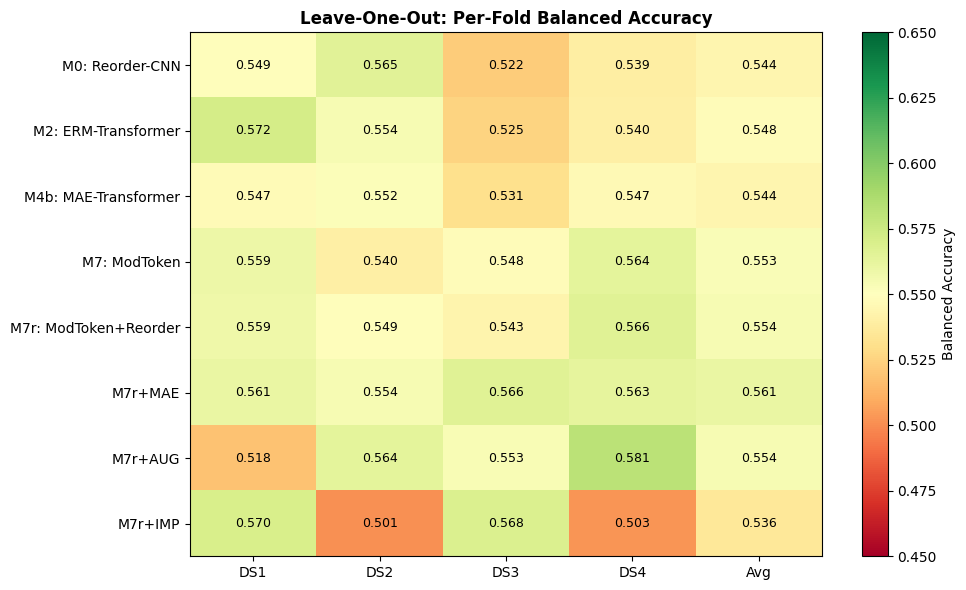

In [9]:
# Heatmap of per-fold balanced accuracy for allbutone
if primary_key in pivots:
    pivot = pivots[primary_key]
    ds_cols = [c for c in pivot.columns if c.startswith("INS-W")]
    
    plot_df = pivot[ds_cols + ["Avg"]].copy()
    plot_df.index = [MODEL_DISPLAY.get(m, m) for m in plot_df.index]
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.5)))
    im = ax.imshow(plot_df.values, cmap="RdYlGn", aspect="auto", vmin=0.45, vmax=0.65)
    
    ax.set_xticks(range(len(plot_df.columns)))
    ax.set_xticklabels([c.replace("INS-W_", "DS") for c in plot_df.columns])
    ax.set_yticks(range(len(plot_df.index)))
    ax.set_yticklabels(plot_df.index)
    
    # Annotate cells
    for i in range(len(plot_df.index)):
        for j in range(len(plot_df.columns)):
            val = plot_df.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)
    
    plt.colorbar(im, ax=ax, label="Balanced Accuracy")
    ax.set_title("Leave-One-Out: Per-Fold Balanced Accuracy", fontweight="bold")
    plt.tight_layout()
    plt.savefig("plots/torch_allbutone_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

## Model Families: Base vs Augmented vs Imputed

In [10]:
# Compare base models vs their AUG and IMP variants across all tasks
families = {
    "CNN (M0)": [
        ("dl_torch_reorder_cnn", "Base"),
        ("dl_torch_reorder_cnn_aug", "+AUG"),
        ("dl_torch_reorder_cnn_imp", "+IMP"),
    ],
    "ModToken (M7r)": [
        ("dl_torch_modality_token_reorder", "Base"),
        ("dl_torch_modality_token_reorder_aug", "+AUG"),
        ("dl_torch_modality_token_reorder_imp", "+IMP"),
        ("dl_torch_modality_token_reorder_mae", "+MAE"),
    ],
}

for family_name, members in families.items():
    print(f"\n{'='*60}")
    print(f"  {family_name} â€” Balanced Accuracy Across Tasks")
    print(f"{'='*60}")
    
    rows = []
    for model_key, variant_label in members:
        row = {"Variant": variant_label}
        for task_name in TASK_DIRS:
            key = (task_name, "test_balanced_acc")
            if key in pivots and model_key in pivots[key].index:
                row[TASK_DISPLAY[task_name]] = pivots[key].loc[model_key, "Avg"]
            else:
                row[TASK_DISPLAY[task_name]] = np.nan
        rows.append(row)
    
    df_family = pd.DataFrame(rows).set_index("Variant")
    print(df_family.round(3).to_string())


  CNN (M0) â€” Balanced Accuracy Across Tasks
         Leave-One-Out  Within-User  Cross-COVID  Overlapping Users
Variant                                                            
Base             0.544        0.587        0.525              0.589
+AUG               NaN          NaN          NaN                NaN
+IMP               NaN          NaN          NaN                NaN

  ModToken (M7r) â€” Balanced Accuracy Across Tasks
         Leave-One-Out  Within-User  Cross-COVID  Overlapping Users
Variant                                                            
Base             0.554        0.653        0.525              0.606
+AUG             0.554        0.657        0.532              0.616
+IMP             0.536        0.551        0.512              0.594
+MAE             0.561        0.652        0.527              0.596


## Missing Results Check

In [11]:
# Check which model x task combinations are missing
print("Missing results (model x task):\n")
any_missing = False
for model in MODEL_ORDER:
    for task_name in TASK_DIRS:
        key = (task_name, "test_balanced_acc")
        if key not in pivots or model not in pivots[key].index:
            print(f"  MISSING: {MODEL_DISPLAY.get(model, model):30s} x {task_name}")
            any_missing = True

if not any_missing:
    print("  All 48 runs complete!")

Missing results (model x task):

  MISSING: M3: Reorder-Transformer        x allbutone
  MISSING: M3: Reorder-Transformer        x single_within_user
  MISSING: M3: Reorder-Transformer        x crosscovid
  MISSING: M3: Reorder-Transformer        x two_overlap
  MISSING: M6: Reorder-Deep               x allbutone
  MISSING: M6: Reorder-Deep               x single_within_user
  MISSING: M6: Reorder-Deep               x crosscovid
  MISSING: M6: Reorder-Deep               x two_overlap
  MISSING: M0+AUG                         x allbutone
  MISSING: M0+AUG                         x single_within_user
  MISSING: M0+AUG                         x crosscovid
  MISSING: M0+AUG                         x two_overlap
  MISSING: M0+IMP                         x allbutone
  MISSING: M0+IMP                         x single_within_user
  MISSING: M0+IMP                         x crosscovid
  MISSING: M0+IMP                         x two_overlap
